# 11 - SHAP sample: EDA, growing the API sample safely, and cutting a modelling set

This notebook opens the assembled matrix from NB10 (`data/processed/shap_feature_matrix.parquet`)
and does three things:

1. **EDA** on the three feature layers (raw, static engineered, API-derived).
2. Shows **how to separate the API-enriched companies** and why you must work on that subset
   (not the full 1.37M) when analysing any API-derived feature.
3. Gives a **safe recipe to grow the API sample**: more companies overnight, without hitting the
   Companies House rate limit and without re-spending API calls on companies already enriched.

The end product is a clean `data/processed/shap_sample.parquet` (enriched companies only, feature
columns only) ready for Shapley analysis.

**Key idea used throughout:** the boolean column `api_enriched` is the single source of truth for
"did this company get real API values, or a sentinel placeholder?".

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))   # repo root on path -> `import src...`

MATRIX_PARQUET = "../data/processed/shap_feature_matrix.parquet"
CATALOG_CSV    = "../data/processed/shap_feature_catalog.csv"
BASE_CSV       = "../data/processed/filtered_bb_sme_sectors.csv"
OUT_SAMPLE     = "../data/processed/shap_sample.parquet"

# pandas reads parquet natively (needs pyarrow, already installed since NB10 wrote this file).
df = pd.read_parquet(MATRIX_PARQUET)
catalog = pd.read_csv(CATALOG_CSV)
print("matrix shape:", df.shape)
print("in-memory size:", round(df.memory_usage(deep=True).sum() / 1e6, 1), "MB")
df.head(3)

matrix shape: (1372321, 91)
in-memory size: 1492.4 MB


,CompanyName,CompanyNumber,RegAddress.CareOf,RegAddress.POBox,RegAddress.AddressLine1,RegAddress.AddressLine2,RegAddress.PostTown,RegAddress.County,RegAddress.Country,RegAddress.PostCode,...,lender_check_status,contracts_won_as_supplier,total_value_won_gbp,avg_value_won_gbp,contracts_given_as_buyer,total_value_given_gbp,total_contracts_linked,total_value_linked_gbp,latest_supplier_award_date,financial_health_concern
0,!ABRIDGE TAX LTD,16092999,NaN,NaN,82 GREAT NORTH ROAD,GREAT NORTH BUSINESS CENTRE,HATFIELD,NaN,UNITED KINGDOM,AL9 5BL,...,Not checked by API,0,0.0,0.0,0,0.0,0,0.0,NaT,True
1,!BIG IMPACT GRAPHICS LIMITED,11743365,NaN,NaN,124 CITY ROAD,NaN,LONDON,NaN,NaN,EC1V 2NX,...,Not checked by API,0,0.0,0.0,0,0.0,0,0.0,NaT,False
2,!NFLECTION ADVISORY LIMITED,15073164,NaN,NaN,74 SANTERS LANE,NaN,POTTERS BAR,HERTFORDSHIRE,ENGLAND,EN6 2DA,...,Not checked by API,0,0.0,0.0,0,0.0,0,0.0,NaT,False


## 1. The three layers

The catalog (written by NB10) tags every column with the layer it belongs to. This matters because
the layers have very different coverage:

- `raw` and `static_engineered`: populated for **all** 1,372,321 companies.
- `api_ch` and `api_contracts`: populated only for the **sample**; everyone else holds a sentinel.

In [2]:
print(catalog["layer"].value_counts().to_string())
print()
# The dtype is a giveaway that these columns are only partly real: pd.NA sentinels leave the
# non-enriched rows as NaN, so an int feature like active_directors arrives as float64.
catalog.sort_values("layer")

layer
raw                  57
api_ch               17
static_engineered     9
api_contracts         8



,variable,layer,dtype,nonnull_frac
66,api_enriched,api_ch,bool,1.000000
67,active_directors,api_ch,object,0.000095
68,recent_director_appointments,api_ch,object,0.000095
69,recent_director_resignations,api_ch,object,0.000095
70,has_recent_director_change,api_ch,object,1.000000
...,...,...,...,...
61,accounts_overdue,static_engineered,bool,1.000000
62,accounts_stale,static_engineered,bool,1.000000
63,size_tier,static_engineered,string,0.655781
64,num_previous_names,static_engineered,int64,1.000000


## 2. Separating the API-enriched companies

This is the one line you need. Everything else in this section is just showing why it matters.

In [3]:
enriched = df[df["api_enriched"]].copy()

n_total = len(df)
n_enriched = len(enriched)
print(f"enriched companies: {n_enriched:,} of {n_total:,} ({n_enriched / n_total:.2%})")

# Contracts coverage is independent of the CH sample (only companies in award notices).
n_with_contract = int((df["contracts_won_as_supplier"] > 0).sum())
print(f"companies with >=1 won contract: {n_with_contract:,}")

enriched companies: 200 of 1,372,321 (0.01%)
companies with >=1 won contract: 0


### Why you must filter first: sentinels poison whole-column statistics

A **sentinel** is a placeholder that means "no real value here" (e.g. `pd.NA` for counts, `False`
for booleans, `0` for contract totals, `NaT` for dates). If you run `.describe()` or a mean over an
API column on the **full** frame, you are averaging in ~1.37M placeholders, which is meaningless.
Always restrict to `df[df.api_enriched]` first.

The cell below shows the same statistic computed both ways so the distortion is obvious.

In [4]:
col = "charges_outstanding"
full_mean = pd.to_numeric(df[col], errors="coerce").mean()          # includes NA sentinels -> skipped
full_nonnull = df[col].notna().mean()
enr_mean = pd.to_numeric(enriched[col], errors="coerce").mean()
print(f"{col}: non-null on full frame = {full_nonnull:.2%}")
print(f"  mean over full frame  : {full_mean:.3f}  (only the enriched rows are non-null anyway)")
print(f"  mean over enriched only: {enr_mean:.3f}")
print()
print("has_lloyds_linked_lender counted on FULL frame (sentinel False hides everyone unenriched):")
print(df["has_lloyds_linked_lender"].value_counts().to_string())
print("\n...and counted on the ENRICHED subset (the honest denominator):")
print(enriched["has_lloyds_linked_lender"].value_counts().to_string())

charges_outstanding: non-null on full frame = 0.01%
  mean over full frame  : 1.771  (only the enriched rows are non-null anyway)
  mean over enriched only: 1.771

has_lloyds_linked_lender counted on FULL frame (sentinel False hides everyone unenriched):
has_lloyds_linked_lender
False    1372300
True          21

...and counted on the ENRICHED subset (the honest denominator):
has_lloyds_linked_lender
False    179
True      21


## 3. EDA on the static engineered layer (all companies)

These are safe to analyse on the full frame; coverage is 100% (except `size_tier` at ~66%, where
the rest are filing-status buckets rather than a size tier).

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_age_years,1372321.0,NaN,NaN,NaN,9.551067,11.084623,0.1,2.1,6.2,13.2,169.8
has_any_charge,1372321,2,False,1243684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_outstanding_charges,1372321,2,False,1279981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
debt_ratio,1372321.0,NaN,NaN,NaN,0.051579,0.207928,0.0,0.0,0.0,0.0,1.0
accounts_overdue,1372321,2,False,1294199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accounts_stale,1372321,2,False,1049855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_tier,899942,4,Micro,501253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_previous_names,1372321.0,NaN,NaN,NaN,0.134462,0.430646,0.0,0.0,0.0,0.0,10.0
has_name_change,1372321,2,False,1223103,NaN,NaN,NaN,NaN,NaN,NaN,NaN


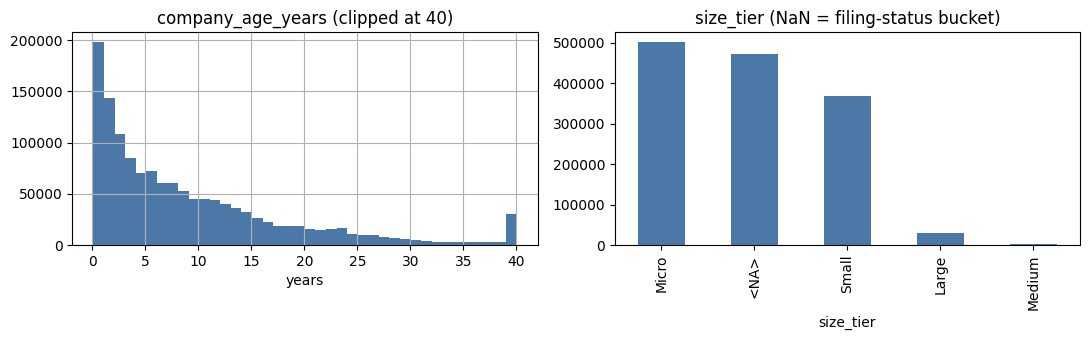

In [5]:
STATIC = [
    "company_age_years", "has_any_charge", "has_outstanding_charges", "debt_ratio",
    "accounts_overdue", "accounts_stale", "size_tier", "num_previous_names", "has_name_change",
]
display(df[STATIC].describe(include="all").T)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["company_age_years"].clip(upper=40).hist(bins=40, ax=ax[0], color="#4C78A8")
ax[0].set_title("company_age_years (clipped at 40)"); ax[0].set_xlabel("years")
df["size_tier"].value_counts(dropna=False).plot.bar(ax=ax[1], color="#4C78A8")
ax[1].set_title("size_tier (NaN = filing-status bucket)")
plt.tight_layout(); plt.show()

## 4. EDA on the API-derived layer (enriched subset only)

Everything here reads from `enriched`, never `df`. Also useful: coverage by sector and size tier,
so you can see whether the prioritised sample skews toward a particular cell.

In [6]:
API_NUMERIC = [
    "active_directors", "recent_director_appointments", "recent_director_resignations",
    "recent_growth_filings", "accounts_filings_count", "charges_outstanding", "charges_total",
]
for c in API_NUMERIC:
    enriched[c] = pd.to_numeric(enriched[c], errors="coerce")
display(enriched[API_NUMERIC].describe().T)

print("Sample coverage by sector x size_tier (enriched company counts):")
display(pd.crosstab(enriched["sector"], enriched["size_tier"], dropna=False))

print("\nBoolean API signals within the enriched subset:")
for c in ["has_recent_director_change", "has_recent_growth_filing",
          "has_lloyds_linked_lender", "has_other_lender", "financial_health_concern"]:
    print(f"  {c:32s}: {enriched[c].mean():.2%} True")

,count,mean,std,min,25%,50%,75%,max
active_directors,131.0,2.587786,1.735911,0.0,1.0,2.0,3.0,9.0
recent_director_appointments,131.0,0.374046,0.871214,0.0,0.0,0.0,0.0,6.0
recent_director_resignations,131.0,0.389313,0.864448,0.0,0.0,0.0,0.5,5.0
recent_growth_filings,131.0,0.328244,1.511203,0.0,0.0,0.0,0.0,13.0
accounts_filings_count,131.0,23.160305,11.252909,0.0,16.0,24.0,29.0,48.0
charges_outstanding,131.0,1.770992,1.444165,1.0,1.0,1.0,2.0,11.0
charges_total,131.0,3.328244,3.500424,1.0,1.0,2.0,4.0,20.0


Sample coverage by sector x size_tier (enriched company counts):


size_tier,Large,Micro,Small,<NA>
sector,,,,
Fast growth & emerging,7,7,9,4
Manufacturing,12,14,41,2
"Technology, legal & professional",23,23,46,12



Boolean API signals within the enriched subset:
  has_recent_director_change      : 19.50% True
  has_recent_growth_filing        : 7.50% True
  has_lloyds_linked_lender        : 10.50% True
  has_other_lender                : 61.50% True
  financial_health_concern        : 67.50% True


## 5. Growing the API sample safely (more companies overnight, no wasted calls)

The static and raw layers already cover all 1.37M companies. The only thing that is sample-limited
is the live Companies House layer, because it costs one round-trip **per company**. To grow it you
must respect two constraints:

### Constraint A: the rate limit
Companies House allows roughly **600 requests per 5 minutes** (about 2 requests/second). Each company
costs about **3 calls** (officers, filing-history, charges; officers and filings paginate at 100/page,
so occasionally more). With the `API_SLEEP = 0.5s` gap between companies you land at roughly
**1 company every ~2 seconds**, which averages under the 2 req/s ceiling. That is about
**1,800/hour**, so a 10-hour overnight run realistically enriches on the order of **15k to 20k**
companies, not the full 1.37M. Getting a live-API column on *every* company is a multi-week job;

FIXS:
1. A bulk download instead of the per-company API. (if it is possible from the CH website)
2. Using Amazon AWS for multi-IP runs, but this would need us to create several API keys linked to real accounts (which might be a challenge)

### Constraint B: do not re-spend calls on companies already enriched
`enrich_companies` has no built-in cache, so re-running NB10 with a bigger `N` would re-call the API
for the companies you already paid for. The fix is to treat the **existing matrix as the cache**:
the rows with `api_enriched == True` are already done, so we only ever call the API on the *delta*
(new prioritised companies minus already-enriched companies) and then merge the new rows back in.

The next cell is **read-only** and just sizes the job. The cell after it actually runs, and is
guarded by `RUN_INCREMENTAL = False` so a run-all makes zero API calls until you opt in.

In [7]:
from src.features import sample

# How far you want the sample to reach in total, and how much you can afford in one sitting.
TARGET_N        = 5000    # desired cumulative size of the CH-API sample
OVERNIGHT_HOURS = 10
SECONDS_PER_COMPANY = 2.0  # ~3 API calls + 0.5s sleep + latency
budget = int(OVERNIGHT_HOURS * 3600 / SECONDS_PER_COMPANY)

# Already-done companies, taken straight from the matrix (this is our cache).
join_key = df["CompanyNumber"].str.strip().str.upper().str.zfill(8)
already = set(join_key[df["api_enriched"]])

# Rebuild the prioritised sample of size TARGET_N from the matrix itself
# (build_api_sample only needs CompanyStatus + Mortgages.NumMortOutstanding, both present as raw).
target_sample = sample.build_api_sample(df, n=TARGET_N)
to_do = target_sample[~target_sample[sample.JOIN_KEY].isin(already)]

print(f"already enriched      : {len(already):,}")
print(f"target sample size    : {TARGET_N:,}")
print(f"delta still to enrich : {len(to_do):,}")
print(f"tonight's budget      : {budget:,} companies (~{OVERNIGHT_HOURS}h)")
print(f"will process tonight  : {min(len(to_do), budget):,}")

already enriched      : 200
target sample size    : 5,000
delta still to enrich : 4,800
tonight's budget      : 18,000 companies (~10h)
will process tonight  : 4,800


In [ ]:
# --- Incremental enrichment: only calls the API on the delta, then updates the matrix in place. ---
# Set to True and run this cell (or the whole notebook) to actually spend API calls.
RUN_INCREMENTAL = False

if RUN_INCREMENTAL:
    from src.features import ch_api
    assert ch_api.has_api_key(), "Set CH_API_KEY in .env before enriching."

    delta = to_do.head(budget).copy()
    print(f"Enriching {len(delta):,} new companies...")
    new = ch_api.enrich_companies(delta, number_col=sample.JOIN_KEY, sleep=API_SLEEP if 'API_SLEEP' in dir() else 0.5)
    new = new.set_index(sample.JOIN_KEY)

    # Write the new API values back into the matrix rows they belong to.
    df[sample.JOIN_KEY] = df["CompanyNumber"].str.strip().str.upper().str.zfill(8)
    mask = df[sample.JOIN_KEY].isin(new.index)
    for c in ch_api.API_FEATURE_SENTINELS:
        df.loc[mask, c] = df.loc[mask, sample.JOIN_KEY].map(new[c])
    df.loc[mask, "api_enriched"] = True

    # Recompute the composite so newly-fetched charges feed it.
    df["financial_health_concern"] = (
        (pd.to_numeric(df["charges_outstanding"], errors="coerce").fillna(0) > 0)
        | df["accounts_overdue"].fillna(False)
        | df["accounts_stale"].fillna(True)
    )
    df = df.drop(columns=sample.JOIN_KEY)

    df.to_parquet(MATRIX_PARQUET, index=False)
    enriched = df[df["api_enriched"]].copy()
    print(f"Done. api_enriched now: {int(df['api_enriched'].sum()):,}. Matrix re-written.")
    print("Re-run from the top to see the updated coverage; the delta shrinks each run (no waste).")
else:
    print("RUN_INCREMENTAL is False; no API calls made. Flip it to True to grow the sample.")

## 6. Cut the SHAP modelling sample

For Shapley analysis we want the companies that actually carry API signal (`api_enriched`), keeping
only the feature columns (drop identifiers, free-text lender strings, and date columns). Static and
raw-numeric features are included alongside the API features so the model can weigh all layers.

Identifier columns (`CompanyNumber`, `CompanyName`, `sector`) are carried but flagged as non-features
so you can join results back later without feeding them to the model.

In [8]:
ID_COLS = ["CompanyNumber", "CompanyName", "sector"]

STATIC_FEATURES = STATIC   # from section 3
RAW_NUMERIC = [
    "Mortgages.NumMortCharges", "Mortgages.NumMortOutstanding",
    "Mortgages.NumMortSatisfied", "Mortgages.NumMortPartSatisfied",
]
API_CH_FEATURES = API_NUMERIC + [
    "has_recent_director_change", "has_recent_growth_filing",
    "has_lloyds_linked_lender", "has_other_lender", "financial_health_concern",
]
API_CONTRACT_FEATURES = [
    "contracts_won_as_supplier", "total_value_won_gbp", "avg_value_won_gbp",
    "contracts_given_as_buyer", "total_value_given_gbp",
    "total_contracts_linked", "total_value_linked_gbp",
]
FEATURE_COLS = STATIC_FEATURES + RAW_NUMERIC + API_CH_FEATURES + API_CONTRACT_FEATURES

model_df = df[df["api_enriched"]][ID_COLS + FEATURE_COLS].copy()

# Coerce the raw + API numeric columns (stored as strings/nullable) to real numbers for modelling.
for c in RAW_NUMERIC + API_NUMERIC + API_CONTRACT_FEATURES:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df.to_parquet(OUT_SAMPLE, index=False)
print("Wrote", OUT_SAMPLE, "->", model_df.shape)
print(f"features: {len(FEATURE_COLS)}  (static {len(STATIC_FEATURES)}, raw {len(RAW_NUMERIC)}, "
      f"api_ch {len(API_CH_FEATURES)}, api_contracts {len(API_CONTRACT_FEATURES)})")
print("\nNull fraction per feature (within the enriched sample):")
print(model_df[FEATURE_COLS].isna().mean().sort_values(ascending=False).round(3).to_string())
model_df.head()

Wrote ../data/processed/shap_sample.parquet -> (200, 35)
features: 32  (static 9, raw 4, api_ch 12, api_contracts 7)

Null fraction per feature (within the enriched sample):
recent_director_resignations      0.345
active_directors                  0.345
recent_director_appointments      0.345
recent_growth_filings             0.345
charges_total                     0.345
charges_outstanding               0.345
accounts_filings_count            0.345
size_tier                         0.090
num_previous_names                0.000
accounts_stale                    0.000
accounts_overdue                  0.000
has_name_change                   0.000
debt_ratio                        0.000
company_age_years                 0.000
has_outstanding_charges           0.000
has_any_charge                    0.000
Mortgages.NumMortPartSatisfied    0.000
Mortgages.NumMortCharges          0.000
Mortgages.NumMortOutstanding      0.000
Mortgages.NumMortSatisfied        0.000
has_recent_director_change

,CompanyNumber,CompanyName,sector,company_age_years,has_any_charge,has_outstanding_charges,debt_ratio,accounts_overdue,accounts_stale,size_tier,...,has_lloyds_linked_lender,has_other_lender,financial_health_concern,contracts_won_as_supplier,total_value_won_gbp,avg_value_won_gbp,contracts_given_as_buyer,total_value_given_gbp,total_contracts_linked,total_value_linked_gbp
75081,03708621,AMIPAK LIMITED,Manufacturing,27.4,True,True,0.40,False,False,Large,...,False,True,True,0,0.0,0.0,0,0.0,0,0.0
179004,01183658,BONAM & BERRY LIMITED,Manufacturing,51.8,True,True,0.20,False,False,Small,...,False,True,True,0,0.0,0.0,0,0.0,0,0.0
179017,01461678,BONAPRENE PRODUCTS LIMITED,Manufacturing,46.6,True,True,0.33,False,False,Small,...,True,True,True,0,0.0,0.0,0,0.0,0,0.0
179024,06767604,BONASYSTEMS EUROPE LTD,Manufacturing,17.6,True,True,0.40,True,False,Small,...,False,True,True,0,0.0,0.0,0,0.0,0,0.0
179070,07404797,BOND BRYAN ARCHITECTS (HOLDINGS) LIMITED,"Technology, legal & professional",15.7,True,True,1.00,False,False,Large,...,False,True,True,0,0.0,0.0,0,0.0,0,0.0


## 7. Summary and next steps

- `enriched = df[df.api_enriched]` is how you isolate companies with real API values; never analyse
  an API column on the full frame (the sentinels make the statistics meaningless).
- Find a way to scale-up APIs calls / try to do bulk downloads
- Extract historical data (a copy of the `data/processed/filtered_bb_sme_sectors.csv` but for previous months/years)
- Aggregate historical data to create deltas variables
- Apply same mehtodology of `notebooks/10_feature_matrix.ipynb` to the aggregated historical data